Vamos a ver cómo funcionan los modelos de visión para clasificar imágenes de perros y gatos.

Torchvision es una librería para trabajar con modelos de visión, Pillow es una librería para trabajar con imágenes en Python y Matplot-lib es una librería para visualizar datos.

In [1]:
%pip install torch torchvision pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch

from PIL import Image

from torchvision import transforms

from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights
)


1. Cargar el modelo preentrenado:

MobileNetV2 es una CNN ya entrenada:
Ha visto millones de imágenes.

In [3]:
weights = MobileNet_V2_Weights.DEFAULT

model = mobilenet_v2(weights=weights)

#Es para evaluarlo, no para entrenarlo, por eso se pone en modo evaluación
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

2. Seleccionamos una imagen:

(np.float64(-0.5), np.float64(650.5), np.float64(470.5), np.float64(-0.5))

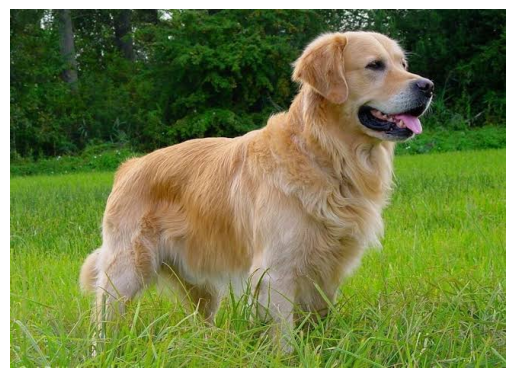

In [4]:
# Cargar la imagen
img = Image.open("fotos/perro.jpg")
#img = Image.open("perro2.jpg")

plt.imshow(img)
plt.axis("off")

3. Preparamos la imagen para que el modelo la pueda entender: los modelos no ven la imagen, sino una matriz numérica.

La CNN espera:

- Tamaño concreto.
- Formato concreto.
- Valores normalizados.

In [5]:
preprocess = weights.transforms()

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) # añadimos una dimension->tensor

In [6]:
print(weights.meta)

{'num_params': 3504872, 'min_size': (1, 1), 'categories': ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', '

4. Inferencia.

- La imagen atraviesa todas las capas de la red neuronal.

- La salida son miles de puntuaciones.

- Una por cada categoría conocida.

In [7]:
with torch.no_grad():
    output = model(input_batch)

5. Mostramos el resultado:

In [8]:
predicted_class = output.argmax().item()

predicted_label = (
    weights.meta["categories"][
        predicted_class
    ]
)

print(
    f"Predicción: {predicted_label}"
)

Predicción: golden retriever


# Ejercicio 1 — Cambiar la imagen

En el ejemplo hemos utilizado una imagen proporcionada en el notebook.

Ahora busca una imagen diferente y realiza el proceso completo:

1. Cargar la imagen.
2. Mostrarla.
3. Preprocesarla.
4. Pasarla por el modelo.
5. Obtener la clase predicha.



In [9]:
weights = MobileNet_V2_Weights.DEFAULT

model = mobilenet_v2(weights=weights)

#Es para evaluarlo, no para entrenarlo, por eso se pone en modo evaluación
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

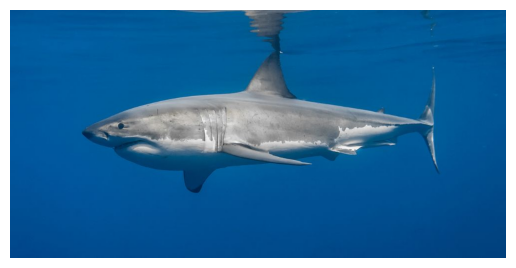

In [10]:
# Cargar la imagen
#img = Image.open("fotos/perro.jpg")
#img = Image.open("fotos/dachshund.jpg")
#img = Image.open("fotos/pitbull.jpg")
#img = Image.open("fotos/goldfish.jpeg")
#img = Image.open("fotos/pez-payaso.jpg")
#img = Image.open("fotos/pollo.jpg")
img = Image.open("fotos/white-shark.jpeg")
#img = Image.open("fotos/white-shark.webp")
plt.imshow(img)
plt.axis("off")

In [11]:
preprocess = weights.transforms()

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) # añadimos una dimension->tensor

In [12]:
with torch.no_grad():
    output = model(input_batch)

In [13]:
predicted_class = output.argmax().item()

predicted_label = (
    weights.meta["categories"][
        predicted_class
    ]
)

print(
    f"Predicción: {predicted_label}"
)

Predicción: great white shark


## Preguntas

- ¿Qué ha predicho el modelo?
    
    En las dos primeras imagenes seleccionados ha predicho dos razas muy parecidas y en la tercera la raza en concreto.
- ¿La predicción es correcta?
    
    En las dos primeras estimaciones no, aunque son razas parecidas. En la tercera opciones si es correcta
- ¿La imagen es adecuada para este modelo?
    
    Si,he intentado mantener la misma estructura en las tres imagenes
Prueba al menos con **3 imágenes diferentes**.

# Ejercicio 2 — Las 5 predicciones principales

Hasta ahora nos hemos quedado únicamente con la clase que tiene la puntuación más alta:

```python
predicted_class = output.argmax().item()

In [14]:
# Convertir las salidas del modelo en probabilidades
probabilidad = torch.softmax(output, dim=1)

# Obtener las 5 predicciones principales
values, indices = torch.topk(probabilidad[0], k=5)

# Obtener los nombres de las clases
categories = weights.meta["categories"]

# Mostrar resultados
for i in range(5):
    class_index = indices[i].item()
    class_name = categories[class_index]
    score = values[i].item()

    print(f"{i + 1}. {class_name}: {score:.2%}")

1. great white shark: 33.78%
2. tiger shark: 16.78%
3. hammerhead: 13.77%
4. coho: 0.35%
5. warplane: 0.32%


# Ejercicio 3 — Comparar imágenes

Selecciona 5 imágenes diferentes.

Para cada una:

1. Ejecuta el modelo.
2. Obtén las 5 predicciones principales.
3. Indica cuál consideras que es la predicción más adecuada.

Crea una tabla resumen:

| Imagen | Predicción 1 | Puntuación | ¿Correcta? |
|---|---|---|---|
| Goldfish | goldfish | 39.70% | Sí |
| dachshund | vizsla | 10.80% | No |
| anemone-fish | anemone-fish | 42.55% | Sí |
| pollo | goldfish | 4.96% | No |
| white-shark| greate white shark | 33.78% | Sí

## Conclusión

¿En qué tipo de imágenes funciona mejor el modelo?

En las pruebas realizadas, ha mostrado mejores condiciones con imagenes mas claras.

¿En cuáles presenta más dificultades?

En las que no tenga la categoria entrenada, enprincipio, mediante "weights.meta", sabemos como ha sifo entrenada, aquellas categorias que no tenga buscara patrones parecidos como es el caso de "Dachsund", don la raza dada es muy parecida.


# Ejercicio 4 — Analizar las predicciones
Hasta ahora has obtenido una predicción. Ahora debes analizar qué está diciendo realmente el modelo.
Tareas:

1. Utiliza las 5 imágenes del ejercicio anterior.
2. Para cada imagen, identifica la primera y la segunda predicción.
3. Calcula o muestra la diferencia entre las puntuaciones de las dos primeras clases.
4. Indica si la predicción principal coincide con lo que aparece en la imagen.
5. Comenta si la diferencia entre las dos primeras predicciones parece grande o pequeña.


Tabla resumen:

| Imagen | Predicción 1 | Predicción 2 | Diferencia cálculo | ¿Correcta? | ¿Es alta la diferencia? |
|---|---|---|---|---|---|
| Goldfish | 39.70% | 0.69% | 39,01 | Sí | Sí |
| dachshund | 10.80% | 6.73% | 4.07% | No | No|
| anemone-fish | 42.55% |  1.33% | 41.22% | Sí | Sí |
| pollo | 4.96% | 4.59% | 0.37% | No | No |
| white-shark(webp)| 60.45% | 7.16% | 53.29% | Sí | Si|
| white-shark(jpeg)| 33.78%% | 16.78%% | 17% | Sí | Si|

# Preguntas:

¿Una puntuación alta garantiza que la predicción sea correcta?

En las pruebas realizadas, si, aquellos con puntuaciones altas ha realizado las predicciones correctas

¿Qué puede significar que dos clases tengan puntuaciones parecidas?

Que tenga dudas con esas dos clases.
    
¿Qué ocurre cuando el modelo tiene dudas entre dos clases?

Que la probabilidad de prediccion para las dos categorias son muy parecidaas.

Entrega: Una tabla con las 5 imágenes, primera predicción, segunda predicción, puntuaciones y una breve interpretación. (lo añadis al notebook)

## Ejercicio 5 — Crear una función de clasificación
Convierte el código que has utilizado hasta ahora en una función reutilizable.
Tareas:

  6. Crea una función llamada clasificar_imagen(ruta).
  7. La función debe recibir la ruta de una imagen.
  8. Debe cargar y preprocesar la imagen.
  9. Debe realizar la inferencia con el modelo.
  10. Debe devolver la predicción principal.
  11. Modifica la función para aceptar también un parámetro top_k que indique cuántas predicciones devolver.
  
# Preguntas:
  ¿Qué partes del código se repiten al clasificar varias imágenes?

  ¿Qué elementos deberían ejecutarse una sola vez, como la carga del modelo?
    
  ¿Qué ventaja tiene utilizar una función en lugar de copiar y pegar el código?

Entrega: Código de la función y pruebas con al menos 3 imágenes.

In [15]:
def clasificar_imagen(ruta_imagen, top_k=1):
    if top_k < 1:
        raise ValueError("top_k debe ser mayor o igual que 1")

    img = Image.open(ruta_imagen).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    input_tensor = preprocess(img)
    input_batch = input_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(input_batch)

    probabilidades = torch.softmax(output, dim=1)
    valores, indices = torch.topk(
        probabilidades[0],
        k=min(top_k, len(weights.meta["categories"]))
    )

    resultados = []

    for valor, indice in zip(valores, indices):
        resultados.append((
            weights.meta["categories"][indice.item()],
            valor.item()
        ))

    for posicion, (clase, probabilidad) in enumerate(resultados, start=1):
        print(f"{posicion}. {clase}: {probabilidad:.2%}")

    return resultados

## Ejercicio 6 — Probar imágenes difíciles
Un modelo puede funcionar de forma diferente según el tipo de imagen que recibe. Diseña una pequeña prueba para explorar sus limitaciones.
Tareas:

12. Busca una imagen con un animal parcialmente oculto.
13. Busca una imagen con varios animales.
14. Busca una imagen borrosa o con poca iluminación.
15. Busca una imagen que sea un dibujo o ilustración de un animal.
16. Busca una imagen que no contenga ningún animal.
17. Clasifica todas las imágenes y registra los resultados.

# Preguntas:
¿En qué casos ha acertado y en cuáles ha fallado?

En este caso, ha fallado en dos imagenes, en la quen o habia animales, que ha intentado adivinar el cereal que tiene la campa y en el dibujo al tener colores tan vivos lo ha confundido con otro objeto.

¿Qué tipo de imágenes parecen ser más difíciles?

Las que contienen colores muy vivos, porque deja de relacionarlos con el animal.

¿Qué ocurre cuando la imagen no pertenece claramente a una de las categorías que el modelo conoce?

Intenta seleccionar una clase parecida al elemento seleccionado

¿El modelo puede devolver una predicción aunque la respuesta no tenga sentido para nosotros?
    
Si, por ejemplo en la del gallo dibujado, el modelo ha devuelto un molinillo. A priori no tiene sentido para nostros pero como usa colores muy vivos el modelo lo relaciona con este otro objeto.

Entrega: Tabla de resultados y una conclusión de 5-10 líneas.

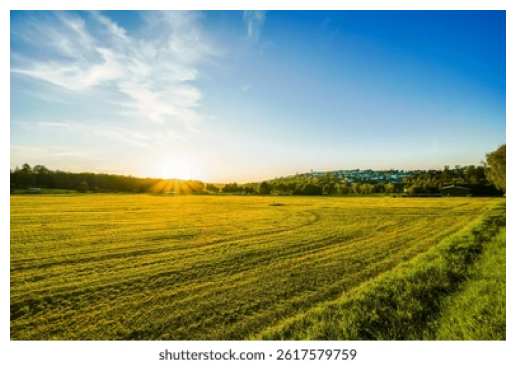

1. rapeseed: 37.67%
2. hay: 3.42%
3. barn: 1.15%
4. valley: 0.85%
5. stone wall: 0.78%
6. harvester: 0.74%


[('rapeseed', 0.3766865134239197),
 ('hay', 0.03419763967394829),
 ('barn', 0.011543679982423782),
 ('valley', 0.008460084907710552),
 ('stone wall', 0.007783424574881792),
 ('harvester', 0.0074435751885175705)]

In [16]:
clasificar_imagen("fotos/campa_sin_animales.webp", top_k=6)



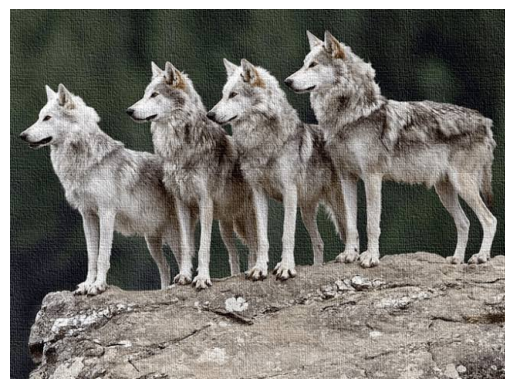

1. timber wolf: 38.27%
2. white wolf: 18.97%
3. red wolf: 13.90%
4. coyote: 9.10%
5. dingo: 3.41%
6. Eskimo dog: 1.54%


[('timber wolf', 0.38273295760154724),
 ('white wolf', 0.18966840207576752),
 ('red wolf', 0.13904334604740143),
 ('coyote', 0.09098844230175018),
 ('dingo', 0.03408988565206528),
 ('Eskimo dog', 0.015407737344503403)]

In [17]:
clasificar_imagen("fotos/manada.jpeg", top_k=6)


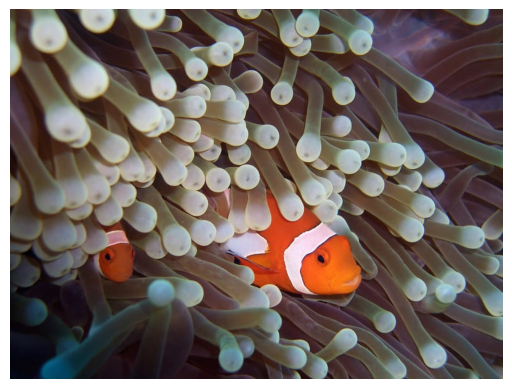

1. anemone fish: 44.48%
2. sea anemone: 4.26%
3. coral reef: 0.36%
4. pinwheel: 0.27%
5. cup: 0.23%
6. bib: 0.23%


[('anemone fish', 0.4448109567165375),
 ('sea anemone', 0.04264633730053902),
 ('coral reef', 0.003567593637853861),
 ('pinwheel', 0.0027001528069376945),
 ('cup', 0.002311712596565485),
 ('bib', 0.002279741456732154)]

In [18]:
clasificar_imagen("fotos/pez-payaso-anemonas.jpg", top_k=6)

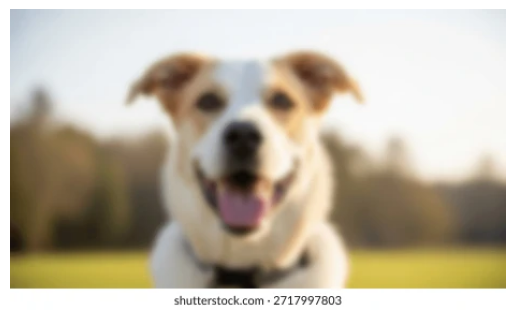

1. Labrador retriever: 5.19%
2. wire-haired fox terrier: 3.78%
3. English foxhound: 3.16%
4. American Staffordshire terrier: 3.04%
5. golden retriever: 2.31%
6. beagle: 2.06%


[('Labrador retriever', 0.051891833543777466),
 ('wire-haired fox terrier', 0.03775333613157272),
 ('English foxhound', 0.0315791592001915),
 ('American Staffordshire terrier', 0.030431773513555527),
 ('golden retriever', 0.023088188841938972),
 ('beagle', 0.020646126940846443)]

In [19]:
clasificar_imagen("fotos/perro3.webp", top_k=6)

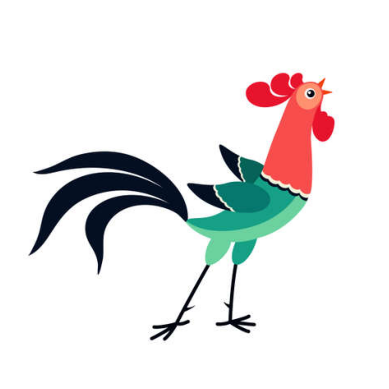

1. pinwheel: 9.98%
2. hook: 2.18%
3. folding chair: 1.71%
4. barrow: 1.42%
5. umbrella: 1.34%
6. wall clock: 1.19%


[('pinwheel', 0.09980491548776627),
 ('hook', 0.02184223383665085),
 ('folding chair', 0.0171163622289896),
 ('barrow', 0.014177980832755566),
 ('umbrella', 0.013372118584811687),
 ('wall clock', 0.011898069642484188)]

In [20]:
clasificar_imagen("fotos/gallo.jpg", top_k=6)

## Ejercicio 7 — Cambiar de modelo
Investiga cómo utilizar otro modelo de visión preentrenado disponible en torchvision.

Tareas:

18. Busca en la documentación de torchvision otro modelo de clasificación de imágenes.

19. Cárgalo utilizando sus pesos preentrenados.

20. Comprueba qué transformaciones de preprocesado recomienda el propio modelo.

21. Utiliza el nuevo modelo para clasificar al menos 3 de las imágenes anteriores.

22. Compara las predicciones obtenidas con MobileNetV2.
# Preguntas:
¿Cómo se carga el nuevo modelo?

Se carga igual que mobilnet, desde torchvision.models, al seleccionar la ayuda CTRL+ ESPACIO, te muestra todos los modelos disponibles, en mi caso he seleccionado resnet18, que es un modelo pequeño

¿Qué preprocesado necesita?

Al igual que mobilnet, hemos cargado los pesos por defecto

¿Produce las mismas clases que MobileNetV2?

Si, produce con las mismas clases

¿Las predicciones coinciden siempre?

No, ha sido mas certero que mobilnet, porque ha sido capaz de sacar mas porcentaje en las imagenes seleccionadas e imagenes mas parecidas en las imagenes que no era capaz de "entender" mobilnet.

¿Qué diferencias observas en el código necesario para utilizar ambos modelos?

Ninguna, he reutilizado el codigo

Entrega: Código utilizado, nombre del modelo elegido y una comparación breve con MobileNetV2.

In [ ]:
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

In [22]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

#Es para evaluarlo, no para entrenarlo, por eso se pone en modo evaluación
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

(np.float64(-0.5), np.float64(1599.5), np.float64(899.5), np.float64(-0.5))

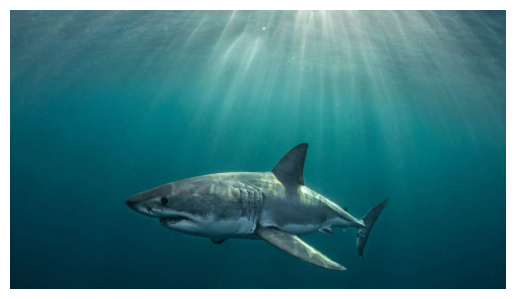

In [23]:
#img = Image.open("fotos/pollo.jpg")

#img = Image.open("fotos/gallo.jpg")
img = Image.open("fotos/white-shark.webp")
plt.imshow(img)
plt.axis("off")

In [24]:
preprocess = weights.transforms()

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) # añadimos una dimension->tensor

In [25]:
with torch.no_grad():
    output = model(input_batch)

In [26]:
predicted_class = output.argmax().item()

predicted_label = (
    weights.meta["categories"][
        predicted_class
    ]
)

print(
    f"Predicción: {predicted_label}"
)

Predicción: great white shark


In [27]:
# Convertir las salidas del modelo en probabilidades
probabilidad = torch.softmax(output, dim=1)

# Obtener las 5 predicciones principales
values, indices = torch.topk(probabilidad[0], k=5)

# Obtener los nombres de las clases
categories = weights.meta["categories"]

# Mostrar resultados
for i in range(5):
    class_index = indices[i].item()
    class_name = categories[class_index]
    score = values[i].item()

    print(f"{i + 1}. {class_name}: {score:.2%}")

1. great white shark: 98.71%
2. tiger shark: 1.16%
3. sturgeon: 0.06%
4. hammerhead: 0.06%
5. killer whale: 0.01%
